# Notebook 04 — Fairness Analysis
**DNSC 6330 Capstone | HMDA LAR 2024**

Goals:
- Measure disparate impact across protected groups (demographic parity, 80% rule)
- Evaluate equalized odds (TPR/FPR) and predictive parity (precision) by group
- Apply the Chouldechova impossibility theorem explicitly
- Apply threshold adjustment as a mitigation
- Summarize residual risks

> **Capstone question answered here:** *How are subgroup errors measured? What risks remain after mitigation?*
>
> **Key theorem (DNSC 6330 Lecture 03):** The Chouldechova impossibility result states that calibration, equal FPR, and equal FNR cannot all hold simultaneously when base rates differ across groups. This is a **value choice**, not a bug.

## 0. Imports

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

import os

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
TABLES_DIR  = os.path.join(BASE_DIR, 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, precision_score, recall_score,
    brier_score_loss
)

# calibration_curve moved to sklearn.calibration in newer sklearn versions
try:
    from sklearn.calibration import calibration_curve
except ImportError:
    from sklearn.metrics import calibration_curve

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 4)

print('Imports OK')
print(f'BASE_DIR: {BASE_DIR}')

Imports OK
BASE_DIR: /Users/tsotnedzeria-personal/Desktop/RML/capstone


In [18]:
# ── Redirect any remaining stale ../outputs/ paths ───────────────────────────
import matplotlib.pyplot as _plt
_orig_savefig = _plt.savefig

def _patched_savefig(fname, *args, **kwargs):
    if isinstance(fname, str):
        if '../outputs/figures/' in fname:
            fname = os.path.join(FIGURES_DIR, os.path.basename(fname))
        elif '../outputs/tables/' in fname:
            fname = os.path.join(TABLES_DIR, os.path.basename(fname))
        elif '../outputs/' in fname:
            fname = os.path.join(BASE_DIR, os.path.basename(fname))
    return _orig_savefig(fname, *args, **kwargs)

_plt.savefig = _patched_savefig
print('Path patch applied.')

Path patch applied.


## 1. Load Artifacts

In [19]:
X_train    = pd.read_parquet(os.path.join(BASE_DIR, 'X_train_imputed.parquet'))
X_test     = pd.read_parquet(os.path.join(BASE_DIR, 'X_test_imputed.parquet'))
y_train    = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
y_test     = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()
prot_train = pd.read_parquet(os.path.join(BASE_DIR, 'prot_train.parquet'))
prot_test  = pd.read_parquet(os.path.join(BASE_DIR, 'prot_test.parquet'))

model = joblib.load(os.path.join(BASE_DIR, 'best_model.pkl'))

with open(os.path.join(BASE_DIR, 'model_meta.json')) as f:
    meta = json.load(f)

# Validate feature alignment — ensures NB04 uses exact same columns model was trained on
expected_cols = meta.get('feature_columns', [])
if expected_cols:
    missing = set(expected_cols) - set(X_test.columns)
    extra   = set(X_test.columns) - set(expected_cols)
    if missing: print(f'⚠ Missing cols in X_test:  {missing}')
    if extra:   print(f'⚠ Extra cols in X_test:    {extra}')
    X_test  = X_test[expected_cols]
    X_train = X_train[expected_cols]
    print(f'Feature alignment OK — {len(expected_cols)} columns')

# Generate predictions using saved threshold
threshold = meta['threshold']
y_prob    = model.predict_proba(X_test)[:, 1]
y_pred    = (y_prob >= threshold).astype(int)

print(f'\nLoaded: {meta["model_name"]} | threshold={threshold:.3f}')
print(f'X_test:  {X_test.shape}  |  approval rate (actual):    {y_test.mean():.2%}')
print(f'                           approval rate (predicted): {y_pred.mean():.2%}')

Feature alignment OK — 23 columns

Loaded: Gradient Boosting | threshold=0.764
X_test:  (1732350, 23)  |  approval rate (actual):    75.72%
                           approval rate (predicted): 85.82%


## 2. Core Fairness Metrics Functions

In [20]:
def group_fairness_metrics(y_true, y_prob, y_pred, group_series, min_n=30):
    """
    Compute a comprehensive fairness metric table per group.
    Covers demographic parity, equalized odds, and predictive parity.
    """
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = np.array(y_pred)
    groups = np.array(group_series)

    rows = []
    for g in np.unique(groups[~pd.isna(groups)]):
        mask = (groups == g)
        if mask.sum() < min_n:
            continue
        yt = y_true[mask]
        yp = y_prob[mask]
        yd = y_pred[mask]

        if len(np.unique(yt)) < 2:
            continue

        tp = ((yd == 1) & (yt == 1)).sum()
        fp = ((yd == 1) & (yt == 0)).sum()
        tn = ((yd == 0) & (yt == 0)).sum()
        fn = ((yd == 0) & (yt == 1)).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan   # Sensitivity / recall
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan   # 1 - Specificity
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan   # Precision

        rows.append({
            'group':          g,
            'n':              mask.sum(),
            'base_rate':      round(yt.mean(), 4),         # actual approval rate
            'pred_rate':      round(yd.mean(), 4),         # predicted approval rate
            'AUC':            round(roc_auc_score(yt, yp), 4),
            'TPR':            round(tpr, 4),
            'FPR':            round(fpr, 4),
            'FNR':            round(fnr, 4),
            'Precision':      round(ppv, 4),
            'F1':             round(f1_score(yt, yd), 4),
            'Brier':          round(brier_score_loss(yt, yp), 4),
        })

    df = pd.DataFrame(rows).set_index('group')

    # Adverse Impact Ratio vs. group with highest predicted approval rate
    max_pred_rate = df['pred_rate'].max()
    df['AIR'] = (df['pred_rate'] / max_pred_rate).round(4)
    df['fails_80pct'] = df['AIR'] < 0.80

    return df.sort_values('pred_rate', ascending=False)

## 3. Demographic Parity & 80% Rule

In [21]:
PROTECTED_COLS = [c for c in [
    'derived_race', 'derived_sex', 'derived_ethnicity', 'applicant_age'
] if c in prot_test.columns]

fairness_tables = {}

for col in PROTECTED_COLS:
    print(f'\n══ Fairness Metrics: {col} ══')
    tbl = group_fairness_metrics(y_test, y_prob, y_pred, prot_test[col])
    fairness_tables[col] = tbl
    print(tbl.to_string())

    flagged = tbl[tbl['fails_80pct']]
    if not flagged.empty:
        print(f'\n  ⚠ 80% rule FAILS for: {flagged.index.tolist()}')
    else:
        print('\n  ✓ 80% rule holds for all groups')


══ Fairness Metrics: derived_race ══
                                                 n  base_rate  pred_rate     AUC     TPR     FPR     FNR  Precision      F1   Brier     AIR  fails_80pct
group                                                                                                                                                   
Joint                                        37823     0.8026     0.9028  0.8547  0.9784  0.5954  0.0216     0.8698  0.9209  0.1185  1.0000        False
Asian                                       104809     0.7868     0.8749  0.8728  0.9805  0.4851  0.0195     0.8817  0.9285  0.1080  0.9691        False
White                                      1110566     0.7822     0.8697  0.8480  0.9660  0.5239  0.0340     0.8688  0.9148  0.1198  0.9633        False
Race Not Available                          305341     0.7225     0.8469  0.8525  0.9719  0.5215  0.0281     0.8291  0.8949  0.1495  0.9381        False
Black or African American                   

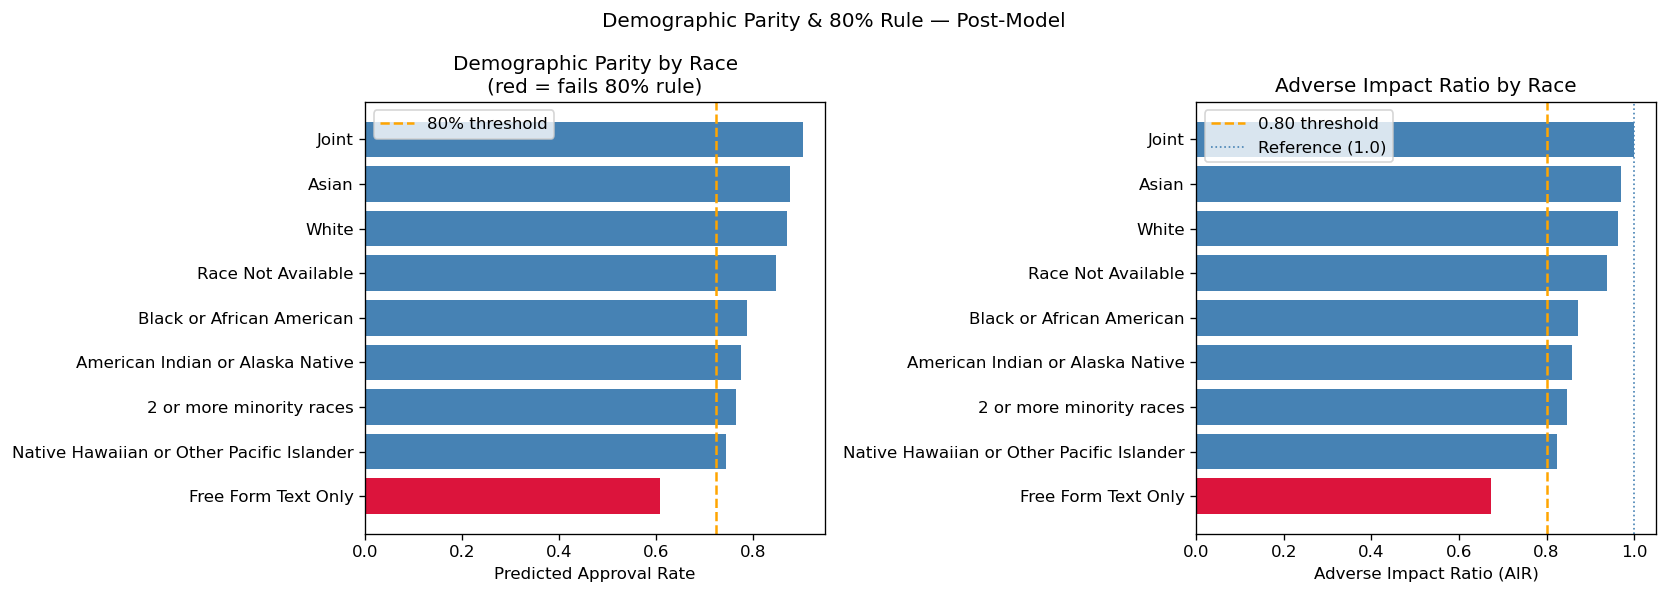

In [23]:
# Visualize: predicted approval rate + AIR by race
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race'].reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Approval rate
    colors = ['crimson' if f else 'steelblue' for f in race_tbl['fails_80pct']]
    axes[0].barh(race_tbl['group'], race_tbl['pred_rate'], color=colors)
    max_rate = race_tbl['pred_rate'].max()
    axes[0].axvline(max_rate * 0.80, color='orange', linestyle='--',
                   linewidth=1.5, label='80% threshold')
    axes[0].set_xlabel('Predicted Approval Rate')
    axes[0].set_title('Demographic Parity by Race\n(red = fails 80% rule)')
    axes[0].legend()
    axes[0].invert_yaxis()

    # AIR
    axes[1].barh(race_tbl['group'], race_tbl['AIR'], color=colors)
    axes[1].axvline(0.80, color='orange', linestyle='--', linewidth=1.5, label='0.80 threshold')
    axes[1].axvline(1.00, color='steelblue', linestyle=':', linewidth=1.0, label='Reference (1.0)')
    axes[1].set_xlabel('Adverse Impact Ratio (AIR)')
    axes[1].set_title('Adverse Impact Ratio by Race')
    axes[1].legend()
    axes[1].invert_yaxis()

    plt.suptitle('Demographic Parity & 80% Rule — Post-Model', fontsize=12)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_demographic_parity.png'))
    plt.show()

## 4. Equalized Odds

Equalized odds requires equal **TPR** and **FPR** across groups.
- Equal TPR = denied applicants have same recall regardless of group
- Equal FPR = approved applicants have same false alarm rate regardless of group

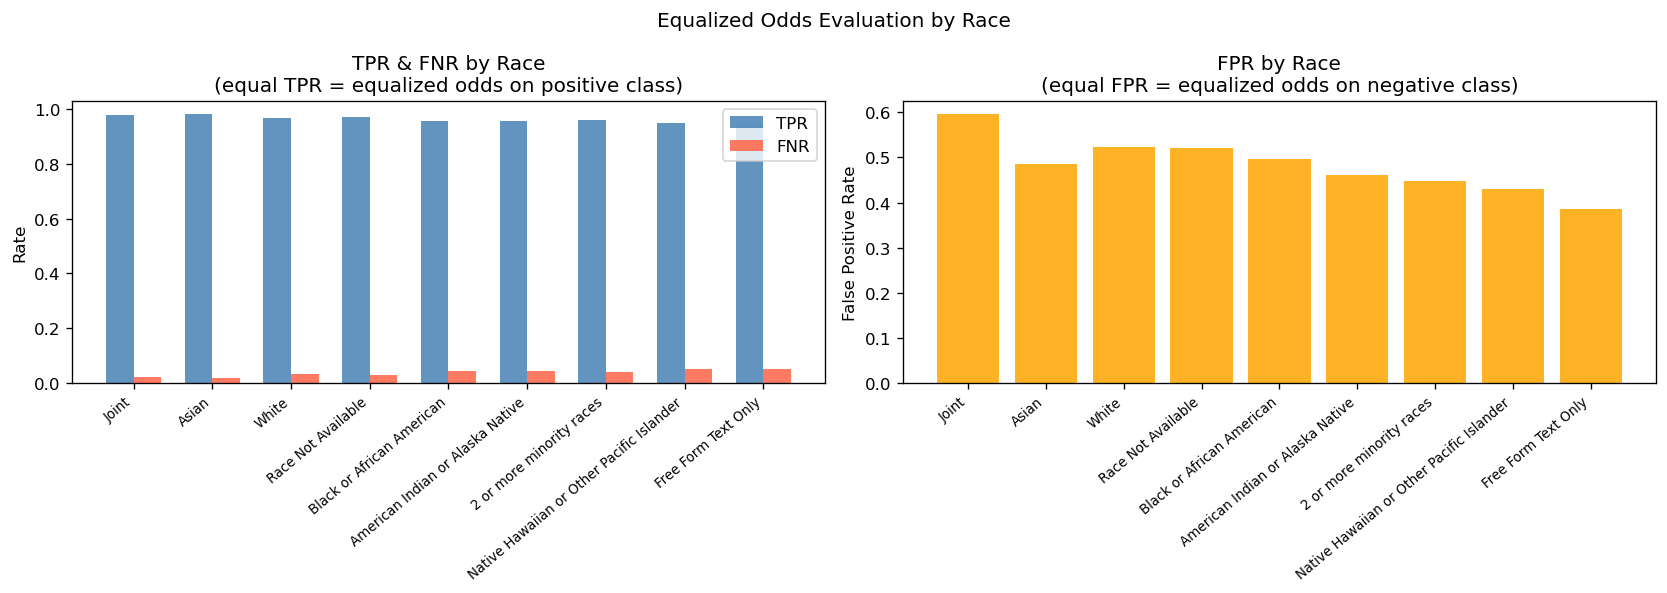

In [24]:
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race'].reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(race_tbl))
    width = 0.35

    # TPR / FNR
    axes[0].bar(x - width/2, race_tbl['TPR'], width, label='TPR', color='steelblue', alpha=0.85)
    axes[0].bar(x + width/2, race_tbl['FNR'], width, label='FNR', color='tomato',    alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(race_tbl['group'], rotation=40, ha='right', fontsize=8)
    axes[0].set_ylabel('Rate')
    axes[0].set_title('TPR & FNR by Race\n(equal TPR = equalized odds on positive class)')
    axes[0].legend()

    # FPR
    axes[1].bar(x, race_tbl['FPR'], color='orange', alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(race_tbl['group'], rotation=40, ha='right', fontsize=8)
    axes[1].set_ylabel('False Positive Rate')
    axes[1].set_title('FPR by Race\n(equal FPR = equalized odds on negative class)')

    plt.suptitle('Equalized Odds Evaluation by Race', fontsize=12)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_equalized_odds.png'))
    plt.show()

## 5. Predictive Parity

Predictive parity requires equal **precision** (PPV) across groups: among those predicted approved, the same fraction should actually be approved regardless of group.

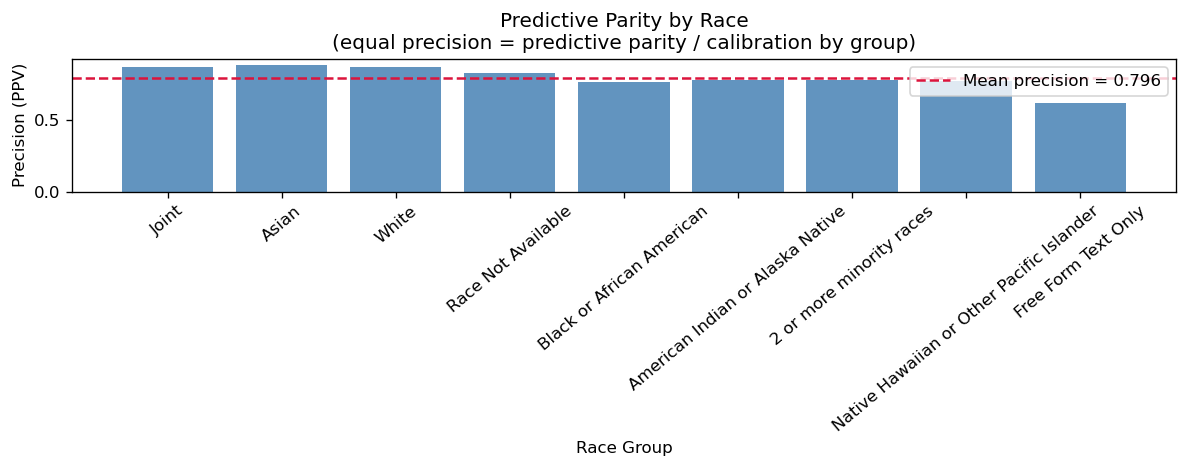

In [25]:
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race'].reset_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(race_tbl['group'], race_tbl['Precision'], color='steelblue', alpha=0.85)
    ax.axhline(race_tbl['Precision'].mean(), color='crimson', linestyle='--',
               linewidth=1.5, label=f'Mean precision = {race_tbl["Precision"].mean():.3f}')
    ax.set_xlabel('Race Group')
    ax.set_ylabel('Precision (PPV)')
    ax.set_title('Predictive Parity by Race\n(equal precision = predictive parity / calibration by group)')
    ax.tick_params(axis='x', rotation=40)
    ax.legend()
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_predictive_parity.png'))
    plt.show()

## 6. Chouldechova Impossibility Theorem

**Theorem (Chouldechova 2017):** When base rates differ across groups, a model cannot simultaneously satisfy:
1. **Calibration** — predicted probabilities match actual outcomes for each group
2. **Equal FPR** — false positive rates are equal across groups
3. **Equal FNR** — false negative rates are equal across groups

We demonstrate this empirically using our HMDA model.

In [26]:
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race']

    print('── Chouldechova Impossibility Check ──')
    print()
    print('Base rates (actual approval rate) by group:')
    print(race_tbl['base_rate'].to_string())
    print()
    print('If base rates differ across groups (which they do),')
    print('then equalizing FPR AND FNR simultaneously is mathematically impossible.')
    print()
    base_rate_range = race_tbl['base_rate'].max() - race_tbl['base_rate'].min()
    fpr_range = race_tbl['FPR'].max() - race_tbl['FPR'].min()
    fnr_range = race_tbl['FNR'].max() - race_tbl['FNR'].min()

    print(f'Base rate spread: {base_rate_range:.4f}')
    print(f'FPR spread:       {fpr_range:.4f}')
    print(f'FNR spread:       {fnr_range:.4f}')
    print()
    print('Governance implication: we must choose which fairness criterion to prioritize.')
    print('For HMDA mortgage lending, equalizing FPR (preventing wrongful denials)')
    print('is most legally relevant under ECOA and the Fair Housing Act.')

── Chouldechova Impossibility Check ──

Base rates (actual approval rate) by group:
group
Joint                                        0.8026
Asian                                        0.7868
White                                        0.7822
Race Not Available                           0.7225
Black or African American                    0.6319
American Indian or Alaska Native             0.6316
2 or more minority races                     0.6169
Native Hawaiian or Other Pacific Islander    0.6044
Free Form Text Only                          0.3959

If base rates differ across groups (which they do),
then equalizing FPR AND FNR simultaneously is mathematically impossible.

Base rate spread: 0.4067
FPR spread:       0.2096
FNR spread:       0.0319

Governance implication: we must choose which fairness criterion to prioritize.
For HMDA mortgage lending, equalizing FPR (preventing wrongful denials)
is most legally relevant under ECOA and the Fair Housing Act.


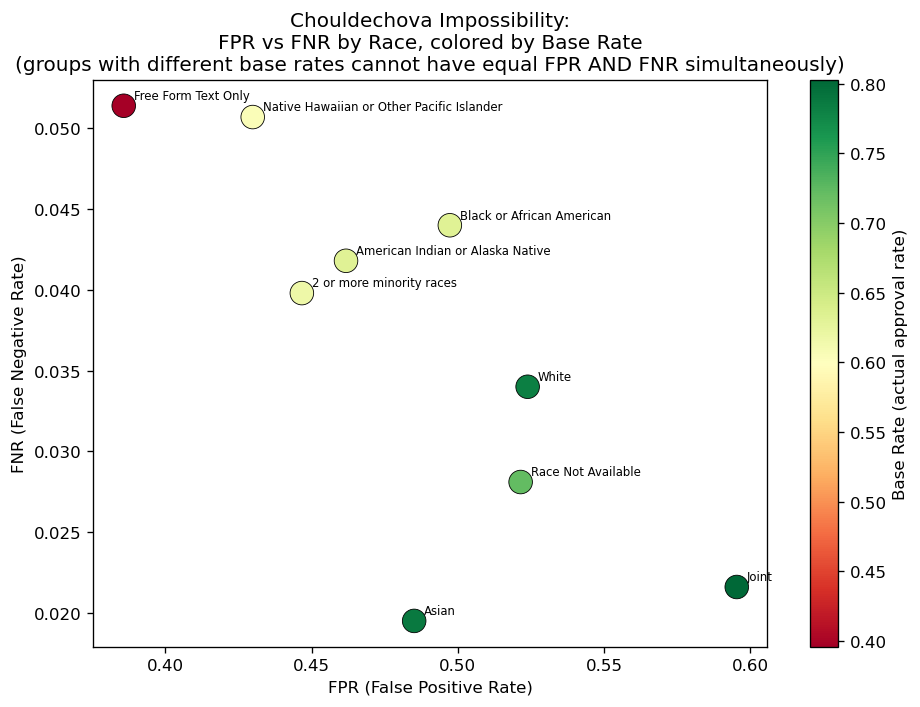

In [28]:
# Visualize the impossibility: FPR vs FNR tradeoff with base rate shown
if 'derived_race' in fairness_tables:
    race_tbl = fairness_tables['derived_race'].reset_index()

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        race_tbl['FPR'], race_tbl['FNR'],
        c=race_tbl['base_rate'], cmap='RdYlGn',
        s=200, zorder=5, edgecolors='black', linewidths=0.5
    )
    for _, row in race_tbl.iterrows():
        ax.annotate(row['group'], (row['FPR'], row['FNR']),
                   textcoords='offset points', xytext=(6, 4), fontsize=7)
    plt.colorbar(scatter, ax=ax, label='Base Rate (actual approval rate)')
    ax.set_xlabel('FPR (False Positive Rate)')
    ax.set_ylabel('FNR (False Negative Rate)')
    ax.set_title('Chouldechova Impossibility:\nFPR vs FNR by Race, colored by Base Rate\n'
                '(groups with different base rates cannot have equal FPR AND FNR simultaneously)')
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_chouldechova.png'))
    plt.show()

## 7. Mitigation — Threshold Adjustment

We apply **group-specific threshold adjustment** (post-processing mitigation) to equalize FPR across groups. We then report the accuracy cost — the price paid in overall performance for improved fairness.

In [29]:
def find_group_threshold(y_true_g, y_prob_g, target_fpr, grid_size=200):
    """
    Find the threshold for a group that brings FPR closest to target_fpr.
    """
    best_thresh = 0.5
    best_diff   = np.inf

    for thresh in np.linspace(0.01, 0.99, grid_size):
        preds = (y_prob_g >= thresh).astype(int)
        tn = ((preds == 0) & (y_true_g == 0)).sum()
        fp = ((preds == 1) & (y_true_g == 0)).sum()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        if not np.isnan(fpr) and abs(fpr - target_fpr) < best_diff:
            best_diff   = abs(fpr - target_fpr)
            best_thresh = thresh

    return best_thresh


if 'derived_race' in prot_test.columns:
    race_col = prot_test['derived_race'].values

    # Target: equalize FPR to the group with lowest FPR (most conservative)
    race_tbl_pre = fairness_tables['derived_race']
    target_fpr = race_tbl_pre['FPR'].min()
    print(f'Target FPR for equalization: {target_fpr:.4f}')
    print()

    # Compute group-specific thresholds
    group_thresholds = {}
    for g in race_tbl_pre.index:
        mask = (race_col == g)
        if mask.sum() < 30:
            group_thresholds[g] = THRESHOLD  # fallback to global
            continue
        g_thresh = find_group_threshold(
            y_test.values[mask], y_prob[mask], target_fpr
        )
        group_thresholds[g] = g_thresh
        print(f'  {g}: threshold = {g_thresh:.4f}')

    # Apply group-specific thresholds
    y_pred_mitigated = np.zeros(len(y_test), dtype=int)
    for g, thresh in group_thresholds.items():
        mask = (race_col == g)
        y_pred_mitigated[mask] = (y_prob[mask] >= thresh).astype(int)
    # Apply global threshold for unmapped groups
    unmapped = ~np.isin(race_col, list(group_thresholds.keys()))
    y_pred_mitigated[unmapped] = (y_prob[unmapped] >= threshold).astype(int)

Target FPR for equalization: 0.3858

  Joint: threshold = 0.8964
  Asian: threshold = 0.8718
  White: threshold = 0.8669
  Race Not Available: threshold = 0.8669
  Black or African American: threshold = 0.8472
  American Indian or Alaska Native: threshold = 0.8226
  2 or more minority races: threshold = 0.8226
  Native Hawaiian or Other Pacific Islander: threshold = 0.8226
  Free Form Text Only: threshold = 0.7635


In [30]:
# Compare pre- and post-mitigation metrics
if 'derived_race' in prot_test.columns:
    print('── Pre-Mitigation ──')
    pre_tbl  = group_fairness_metrics(y_test, y_prob, y_pred,             prot_test['derived_race'])
    print(pre_tbl[['pred_rate', 'AIR', 'FPR', 'FNR', 'AUC']].to_string())

    print('\n── Post-Mitigation (threshold adjustment) ──')
    post_tbl = group_fairness_metrics(y_test, y_prob, y_pred_mitigated,   prot_test['derived_race'])
    print(post_tbl[['pred_rate', 'AIR', 'FPR', 'FNR', 'AUC']].to_string())

    # Accuracy cost
    acc_pre  = accuracy_score(y_test, y_pred)
    acc_post = accuracy_score(y_test, y_pred_mitigated)
    f1_pre   = f1_score(y_test, y_pred)
    f1_post  = f1_score(y_test, y_pred_mitigated)

    print(f'\nAccuracy cost of mitigation: {acc_pre:.4f} → {acc_post:.4f} (Δ={acc_post - acc_pre:+.4f})')
    print(f'F1 cost of mitigation:       {f1_pre:.4f} → {f1_post:.4f} (Δ={f1_post - f1_pre:+.4f})')

── Pre-Mitigation ──
                                           pred_rate     AIR     FPR     FNR     AUC
group                                                                               
Joint                                         0.9028  1.0000  0.5954  0.0216  0.8547
Asian                                         0.8749  0.9691  0.4851  0.0195  0.8728
White                                         0.8697  0.9633  0.5239  0.0340  0.8480
Race Not Available                            0.8469  0.9381  0.5215  0.0281  0.8525
Black or African American                     0.7872  0.8720  0.4973  0.0440  0.8426
American Indian or Alaska Native              0.7753  0.8588  0.4618  0.0418  0.8672
2 or more minority races                      0.7635  0.8457  0.4467  0.0398  0.8787
Native Hawaiian or Other Pacific Islander     0.7438  0.8239  0.4299  0.0507  0.8634
Free Form Text Only                           0.6086  0.6741  0.3858  0.0514  0.8687

── Post-Mitigation (threshold adjustment) ─

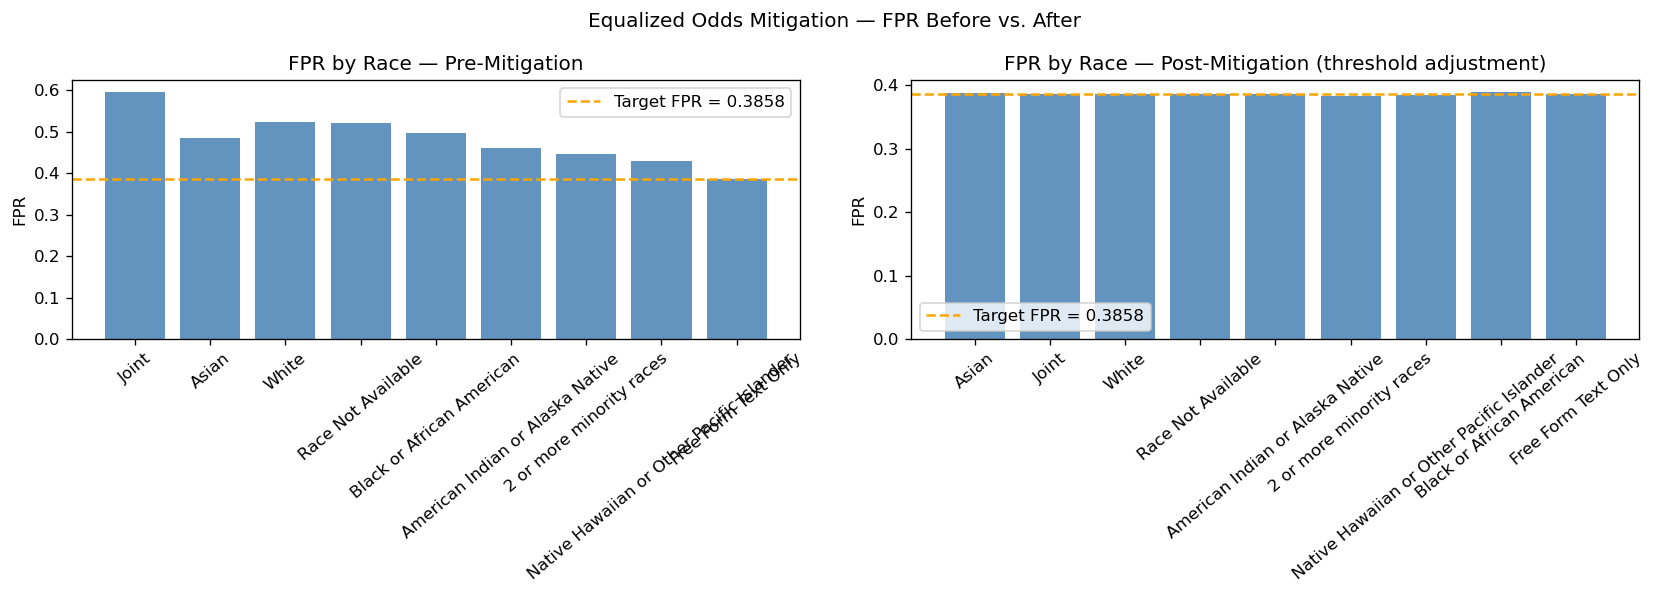

In [31]:
# Visualize FPR before and after mitigation
if 'derived_race' in prot_test.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (tbl, title) in zip(axes, [
        (pre_tbl.reset_index(),  'FPR by Race — Pre-Mitigation'),
        (post_tbl.reset_index(), 'FPR by Race — Post-Mitigation (threshold adjustment)'),
    ]):
        ax.bar(tbl['group'], tbl['FPR'], color='steelblue', alpha=0.85)
        ax.axhline(target_fpr, color='orange', linestyle='--',
                  linewidth=1.5, label=f'Target FPR = {target_fpr:.4f}')
        ax.set_ylabel('FPR')
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=40)
        ax.legend()

    plt.suptitle('Equalized Odds Mitigation — FPR Before vs. After', fontsize=12)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, '04_mitigation_fpr.png'))
    plt.show()

## 8. Residual Risk Summary

Per capstone question 4: *What risks remain after mitigation?*

In [32]:
residual_risks = pd.DataFrame([
    {
        'Risk':        'Proxy discrimination',
        'Severity':    'High',
        'Mitigated':   'Partial',
        'Description': 'Geographic features (census tract, county) loaded but excluded from model. '
                       'However DTI, loan amount, and property value may still encode race/income '
                       'correlations as softer proxies.'
    },
    {
        'Risk':        'Sample selection bias',
        'Severity':    'Medium',
        'Mitigated':   'No',
        'Description': 'Filtered values 4-8 (withdrawn, incomplete) are non-random by group — '
                       'represents 29.4% of raw records; withdrawal rates differ across racial groups.'
    },
    {
        'Risk':        'Intersectionality',
        'Severity':    'Medium',
        'Mitigated':   'No',
        'Description': 'Race x sex x income interactions not measured; aggregate metrics mask '
                       'compound disadvantage (e.g. Black women vs. White men).'
    },
    {
        'Risk':        'Temporal drift',
        'Severity':    'Medium',
        'Mitigated':   'No',
        'Description': 'Model trained on 2024 LAR; fairness properties may degrade as interest '
                       'rates, lending norms, or applicant demographics shift over time.'
    },
    {
        'Risk':        'Chouldechova impossibility',
        'Severity':    'Structural',
        'Mitigated':   'By design',
        'Description': 'Cannot equalize FPR, FNR, and calibration simultaneously given differing '
                       'base rates (38.4pp spread). FPR equalization chosen as most legally '
                       'relevant under ECOA and Fair Housing Act.'
    },
    {
        'Risk':        'Feedback loop',
        'Severity':    'High (if deployed)',
        'Mitigated':   'No',
        'Description': 'Denials reduce future applicants from certain groups, compressing future '
                       'training data and amplifying existing disparities over time.'
    },
    {
        'Risk':        'Credit score model type as proxy',  # ADDED
        'Severity':    'Low',
        'Mitigated':   'Partial',
        'Description': 'Collapsed applicant_credit_score_type to binary (has_credit_score). '
                       'Absence of a credit score correlates with lower income and minority groups — '
                       'monitored but retained as legitimate underwriting signal.'
    },
    {
        'Risk':        'GBT model opacity',                 # ADDED — since we switched to GBT
        'Severity':    'Medium',
        'Mitigated':   'Partial',
        'Description': 'Gradient Boosting is less interpretable than Logistic Regression. '
                       'Mitigated via SHAP and LIME explanations in NB05, but model internals '
                       'are not directly auditable by regulators.'
    },
])

print('── Residual Risk Summary ──')
print(residual_risks.to_string(index=False))

# ── Save residual risk table ──────────────────────────────────────────────────
residual_risks.to_csv(os.path.join(TABLES_DIR, '04_residual_risks.csv'), index=False)
print(f'Saved residual risks → {os.path.join(TABLES_DIR, "04_residual_risks.csv")}')

── Residual Risk Summary ──
                            Risk           Severity Mitigated                                                                                                                                                                                                Description
            Proxy discrimination               High   Partial                       Geographic features (census tract, county) loaded but excluded from model. However DTI, loan amount, and property value may still encode race/income correlations as softer proxies.
           Sample selection bias             Medium        No                                                       Filtered values 4-8 (withdrawn, incomplete) are non-random by group — represents 29.4% of raw records; withdrawal rates differ across racial groups.
               Intersectionality             Medium        No                                                                              Race x sex x income interactions not m

In [33]:
# Save all fairness tables
for col, tbl in fairness_tables.items():
    save_path = os.path.join(TABLES_DIR, f'04_fairness_{col}.csv')
    tbl.to_csv(save_path)
    print(f'Saved → {save_path}')

# Save threshold metadata
threshold_meta = {
    'global_threshold': float(threshold),
    'target_fpr':       float(target_fpr),
    'group_thresholds': {k: float(v) for k, v in group_thresholds.items()},
}
with open(os.path.join(BASE_DIR, 'threshold_meta.json'), 'w') as f:
    json.dump(threshold_meta, f, indent=2)
print(f'Saved → threshold_meta.json')
print(json.dumps(threshold_meta, indent=2))

Saved → /Users/tsotnedzeria-personal/Desktop/RML/capstone/tables/04_fairness_derived_race.csv
Saved → /Users/tsotnedzeria-personal/Desktop/RML/capstone/tables/04_fairness_derived_sex.csv
Saved → /Users/tsotnedzeria-personal/Desktop/RML/capstone/tables/04_fairness_derived_ethnicity.csv
Saved → /Users/tsotnedzeria-personal/Desktop/RML/capstone/tables/04_fairness_applicant_age.csv
Saved → threshold_meta.json
{
  "global_threshold": 0.7642165930888889,
  "target_fpr": 0.3858,
  "group_thresholds": {
    "Joint": 0.8964321608040201,
    "Asian": 0.8718090452261307,
    "White": 0.8668844221105528,
    "Race Not Available": 0.8668844221105528,
    "Black or African American": 0.8471859296482412,
    "American Indian or Alaska Native": 0.8225628140703518,
    "2 or more minority races": 0.8225628140703518,
    "Native Hawaiian or Other Pacific Islander": 0.8225628140703518,
    "Free Form Text Only": 0.7634673366834172
  }
}
